# U05 · 神经网络练习

4 道题。最后一道是**手写一个三层 MLP 做分类**，是本单元过关标准。


## 练习 5.1 · Softmax + 交叉熵

三类分类问题，三个样本的 logits 和真实标签如下：
```
logits = [[2.0,  1.0, 0.1],   ← 样本1
          [0.5,  2.5, 0.2],   ← 样本2
          [0.1, -1.0, 3.0]]   ← 样本3
labels = [0, 1, 2]            ← 真实类别
```

**任务**：
1. 先**手算**每个样本的 softmax 概率（保留 2 位小数即可）
2. 再**手算**每个样本的 cross-entropy loss
3. 最后用 PyTorch 验证


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

logits = torch.tensor([[2.0,  1.0, 0.1],
                       [0.5,  2.5, 0.2],
                       [0.1, -1.0, 3.0]]) # (3, 3)
labels = torch.tensor([0, 1, 2]) # (3,)

# TODO 1: 用 F.softmax 算每个样本的概率
probs = F.softmax(logits, dim=1)      # 提示：F.softmax(logits, dim=1)
print('softmax:\n', probs)

# TODO 2: 用 nn.CrossEntropyLoss 算 loss
loss = nn.CrossEntropyLoss()(logits, labels)      # 提示：nn.CrossEntropyLoss()(logits, labels)
print('CrossEntropy loss:', loss)

# TODO 3: 验证：手动用 -log(p_true) 算
# 提示：probs[range(3), labels] 取出每个样本真实类的概率
manual_loss = -torch.log(probs[range(3), labels]).mean()
print('手动 loss:', manual_loss)


softmax:
 tensor([[0.6590, 0.2424, 0.0986],
        [0.1095, 0.8093, 0.0811],
        [0.0513, 0.0171, 0.9317]])
CrossEntropy loss: tensor(0.2331)
手动 loss: tensor(0.2331)


In [10]:
import torch
import numpy as np
logits = torch.tensor([[2.0,  1.0, 0.1],
                       [0.5,  2.5, 0.2],
                       [0.1, -1.0, 3.0]]) # (3, 3)
labels = torch.tensor([0, 1, 2]) # (3,)

print(torch.exp(logits[range(3)]))
softmax = torch.exp(logits[range(3)])/torch.exp(logits[range(3)]).sum(1,keepdim=True)
print(torch.exp(logits[range(3)]).sum(1).shape)
print(torch.exp(logits[range(3)]).sum(1,keepdim=True).shape)
manual_loss = -torch.log(softmax[range(3), labels])# .mean()
print(manual_loss)





tensor([[ 7.3891,  2.7183,  1.1052],
        [ 1.6487, 12.1825,  1.2214],
        [ 1.1052,  0.3679, 20.0855]])
torch.Size([3])
torch.Size([3, 1])
tensor([0.4170, 0.2116, 0.0708])


## 练习 5.2 · 写一个 MLP

实现一个 MLP 类，结构：
```
输入 (batch, 784)            # 28x28 flatten 的数字图像
  → Linear(784, 128) + ReLU
  → Linear(128, 64)  + ReLU
  → Linear(64, 10)   ← 10 个数字类别，不加激活
输出 (batch, 10)
```


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: 定义 fc1, fc2, fc3
        self.fc1 = nn.Linear(in_features=784, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=64)
        self.fc3 = nn.Linear(in_features=64, out_features=10)


    def forward(self, x):
        # TODO: 实现前向
        x= F.relu(self.fc1(x))
        x= F.relu(self.fc2(x))
        x= self.fc3(x)
        return x

# 自检
model = MLP()
x = torch.randn(16, 784)
y = model(x)
print('输出 shape:', y.shape)
assert y.shape == (16, 10), f'shape 错: {y.shape}'
print('参数总数:', sum(p.numel() for p in model.parameters()))
print('✅ 通过')
print(784 * 128 + 128 * 64 + 64 * 10 + 128 + 64 + 10)


输出 shape: torch.Size([16, 10])
参数总数: 109386
✅ 通过
109386


## 练习 5.3 · 用 DataLoader 走一个 batch

用 5.2 的 MLP，配合 DataLoader 跑**一个 batch** 的完整训练步（5 步循环跑一次）。

目的：熟悉数据流。


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(0)

# 造假数据：1000 个 (784维输入, 0~9 标签)
X = torch.randn(1000, 784)
y = torch.randint(0, 10, (1000,))

class MyDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# TODO 1: 创建 dataset 和 loader（batch_size=32, shuffle=True）
ds = MyDataset(X, y)
loader = DataLoader(ds, batch_size = 32, shuffle = True)

# TODO 2: 创建模型、loss、optimizer
model = MLP()      # MLP()
loss_fn = nn.CrossEntropyLoss()    # nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # torch.optim.Adam(model.parameters(), lr=1e-3)

# TODO 3: 取出 1 个 batch，跑一次完整 5 步
if loader is not None:
    for xb, yb in loader:
        # 5 步循环
        y_pred = model(xb)
        loss = loss_fn(y_pred, yb)
        loss.backward()
        optimizer.step()
        print('xb:', xb.shape, 'yb:', yb.shape)
        # print('loss:', loss.item())
        optimizer.zero_grad()
        break    # 只跑一个 batch


xb: torch.Size([32, 784]) yb: torch.Size([32])


## 练习 5.4 🌟 · 完整分类训练（过关标准）

把 5.2 的 MLP + 5.3 的 DataLoader 组合起来，做一个**完整训练**：
- 数据：人造 10 类分类数据（1000 训练 + 200 验证）
- 训练 20 epochs
- 每个 epoch 末打印 train_loss / val_loss / val_accuracy
- 最后画两条 loss 曲线

**过关标准**：val_accuracy 显著高于随机猜测（10%）。


torch.Size([10, 20])
epoch  0  train_loss=2.4877  val_loss=2.3554  val_acc=5.0%
epoch  1  train_loss=2.2021  val_loss=2.1057  val_acc=30.0%
epoch  2  train_loss=1.9542  val_loss=1.8738  val_acc=45.0%
epoch  3  train_loss=1.7304  val_loss=1.6626  val_acc=45.0%
epoch  4  train_loss=1.5257  val_loss=1.4718  val_acc=70.0%
epoch  5  train_loss=1.3421  val_loss=1.2966  val_acc=75.0%
epoch  6  train_loss=1.1762  val_loss=1.1362  val_acc=85.0%
epoch  7  train_loss=1.0224  val_loss=0.9912  val_acc=85.0%
epoch  8  train_loss=0.8863  val_loss=0.8630  val_acc=100.0%
epoch  9  train_loss=0.7688  val_loss=0.7488  val_acc=100.0%
epoch 10  train_loss=0.6640  val_loss=0.6502  val_acc=100.0%
epoch 11  train_loss=0.5747  val_loss=0.5672  val_acc=100.0%
epoch 12  train_loss=0.4989  val_loss=0.4960  val_acc=100.0%
epoch 13  train_loss=0.4322  val_loss=0.4353  val_acc=100.0%
epoch 14  train_loss=0.3765  val_loss=0.3832  val_acc=100.0%
epoch 15  train_loss=0.3296  val_loss=0.3382  val_acc=100.0%
epoch 16  tr

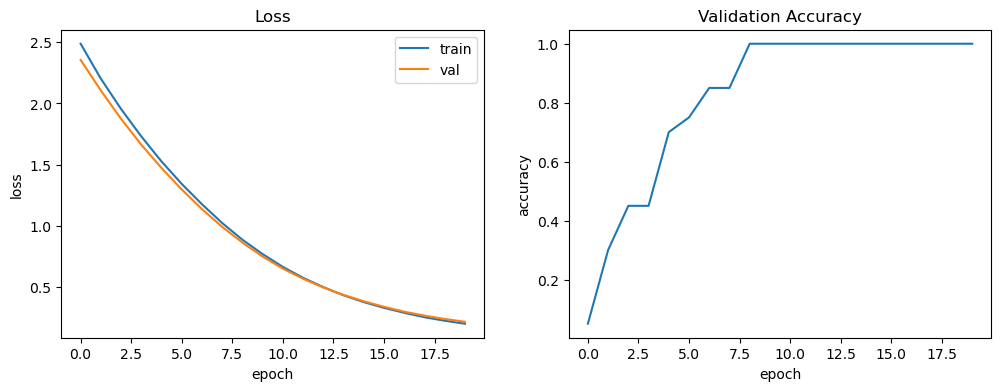

In [ ]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)

# ===== 1. 造一个有规律的分类数据 =====
# 每个类别有自己的中心点，样本 = 中心 + 噪声
N_CLASS = 10 # 10分类
DIM = 20   # 特征维
centers = torch.randn(N_CLASS, DIM) * 3       # 10 个类的中心(10, 20)
print(centers.shape)
def make_data(n_per_class):
    X, y = [], []
    for c in range(N_CLASS): # 每个类别
        x_c = centers[c] + torch.randn(n_per_class, DIM)
        X.append(x_c)
        y.append(torch.full((n_per_class,), c))
    return torch.cat(X), torch.cat(y)

X_train, y_train = make_data(100)             # 1000 训练
X_val,   y_val   = make_data(n_per_class=20)              # 200 验证

class TabDS(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(TabDS(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(TabDS(X_val,   y_val),   batch_size=32)

# ===== 2. TODO: 定义 MLP（输入 20 维，2 隐藏层 64，输出 10）=====
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.ln1 = nn.Linear(20, 64)
        self.ln2 = nn.Linear(64, 10)
    def forward(self, x):
        # TODO
        x = F.relu(self.ln1(x))
        x = self.ln2(x)
        return x

# ===== 3. 训练 =====
model = MLP()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses, val_losses, val_accs = [], [], []

for epoch in range(20):
    # ---- train ----
    model.train()
    train_loss_sum, n_train = 0.0, 0
    for xb, yb in train_loader:
        # TODO: 5 步循环
        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item() * xb.size(0); n_train += xb.size(0)
        pass
    train_losses.append(train_loss_sum / max(n_train, 1))

    # ---- eval ----
    model.eval()
    val_loss_sum, correct, n_val = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model(xb)
            loss = loss_fn(logits, yb)
            val_loss_sum += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            n_val += xb.size(0)
    val_losses.append(val_loss_sum / n_val)
    val_accs.append(correct / n_val)

    print(f'epoch {epoch:2d}  train_loss={train_losses[-1]:.4f}  '
          f'val_loss={val_losses[-1]:.4f}  val_acc={val_accs[-1]*100:.1f}%')

# ===== 4. 画曲线 =====
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, label='train')
axes[0].plot(val_losses, label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend()
axes[0].set_title('Loss')
axes[1].plot(val_accs)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy')
axes[1].set_title('Validation Accuracy')
plt.show()


---
## ✅ 过关标准

- [ ] 5.1 softmax / CE 手算与 PyTorch 一致
- [ ] 5.2 MLP 输出 (16, 10) 通过 assert
- [ ] 5.3 一个 batch 跑通 5 步训练
- [ ] 5.4 **val_accuracy > 80%**（数据本身可分性高，简单 MLP 应能达到 90%+）🎯

全部跑通告诉我 **「U5 做完了」**，进入 **U06 · 词嵌入 + RNN 入门**。

🔥 U5 最重要的认知：**分类损失 = CrossEntropy，自带 Softmax，标签是整数索引**。
